# Energy Demand Forecasting

In [1]:
import numpy as np 
import pandas as pd 
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error,root_mean_squared_error,mean_absolute_error

In [2]:
df = pd.read_csv("AEP_hourly.csv")
df.head()

,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0


In [3]:
df['Datetime'] = pd.to_datetime(df['Datetime'])

In [4]:
df.set_index('Datetime',inplace=True)

In [5]:
print(df.head())

                      AEP_MW
Datetime                    
2004-12-31 01:00:00  13478.0
2004-12-31 02:00:00  12865.0
2004-12-31 03:00:00  12577.0
2004-12-31 04:00:00  12517.0
2004-12-31 05:00:00  12670.0


In [6]:
print(df[df.index.duplicated()])

                      AEP_MW
Datetime                    
2014-11-02 02:00:00  13190.0
2015-11-01 02:00:00  10542.0
2016-11-06 02:00:00  11008.0
2017-11-05 02:00:00  10446.0


In [7]:
df = df[~df.index.duplicated(keep='first')]

In [8]:
print(df[df.index.duplicated()])

Empty DataFrame
Columns: [AEP_MW]
Index: []


In [9]:
df.sort_index(inplace=True)

In [10]:
size = int(len(df)*0.8)
train = df.iloc[:size]
test = df.iloc[size:]

#### Plotting the actual training and testing data

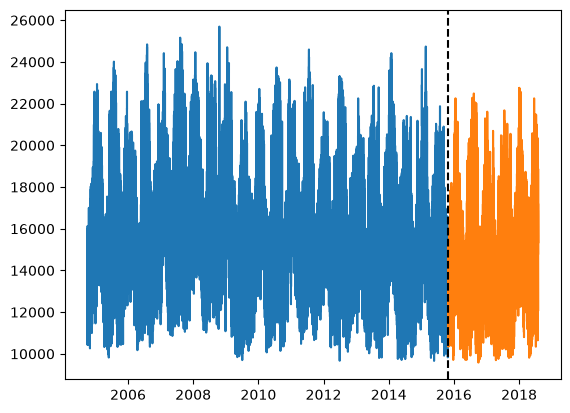

In [11]:
import matplotlib.pyplot as plt

plt.plot(train.index,train['AEP_MW'],label="Training set")
plt.plot(test.index,test['AEP_MW'],label="Testing set")
plt.axvline(df[size:size+1].index,color='black',ls='--')
plt.show()

### Creating the Features for training the XGBoost Regressor

In [12]:
def create_features(df):
    """
    Create time series features based on time series index.
    """
    df = df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week
    return df

df = create_features(df)
df.head()

,AEP_MW,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear
Datetime,,,,,,,,,
2004-10-01 01:00:00,12379.0,1,4,4,10,2004,275,1,40
2004-10-01 02:00:00,11935.0,2,4,4,10,2004,275,1,40
2004-10-01 03:00:00,11692.0,3,4,4,10,2004,275,1,40
2004-10-01 04:00:00,11597.0,4,4,4,10,2004,275,1,40
2004-10-01 05:00:00,11681.0,5,4,4,10,2004,275,1,40


In [13]:
df['AEP_MW_lag1'] = df['AEP_MW'].shift(1)
df['AEP_MW_lag2'] = df['AEP_MW'].shift(2)
df['AEP_MW_lag3'] = df['AEP_MW'].shift(3)
df['AEP_MW_lag4'] = df['AEP_MW'].shift(4)
df['AEP_MW_lag5'] = df['AEP_MW'].shift(5)

In [14]:
print(df.head())

                      AEP_MW  hour  dayofweek  quarter  month  year  \
Datetime                                                              
2004-10-01 01:00:00  12379.0     1          4        4     10  2004   
2004-10-01 02:00:00  11935.0     2          4        4     10  2004   
2004-10-01 03:00:00  11692.0     3          4        4     10  2004   
2004-10-01 04:00:00  11597.0     4          4        4     10  2004   
2004-10-01 05:00:00  11681.0     5          4        4     10  2004   

                     dayofyear  dayofmonth  weekofyear  AEP_MW_lag1  \
Datetime                                                              
2004-10-01 01:00:00        275           1          40          NaN   
2004-10-01 02:00:00        275           1          40      12379.0   
2004-10-01 03:00:00        275           1          40      11935.0   
2004-10-01 04:00:00        275           1          40      11692.0   
2004-10-01 05:00:00        275           1          40      11597.0   

    

In [15]:
df.dropna(inplace=True)
print(df.head())

                      AEP_MW  hour  dayofweek  quarter  month  year  \
Datetime                                                              
2004-10-01 06:00:00  12280.0     6          4        4     10  2004   
2004-10-01 07:00:00  13692.0     7          4        4     10  2004   
2004-10-01 08:00:00  14618.0     8          4        4     10  2004   
2004-10-01 09:00:00  14903.0     9          4        4     10  2004   
2004-10-01 10:00:00  15118.0    10          4        4     10  2004   

                     dayofyear  dayofmonth  weekofyear  AEP_MW_lag1  \
Datetime                                                              
2004-10-01 06:00:00        275           1          40      11681.0   
2004-10-01 07:00:00        275           1          40      12280.0   
2004-10-01 08:00:00        275           1          40      13692.0   
2004-10-01 09:00:00        275           1          40      14618.0   
2004-10-01 10:00:00        275           1          40      14903.0   

    

### Line Plot of the one week hourly data

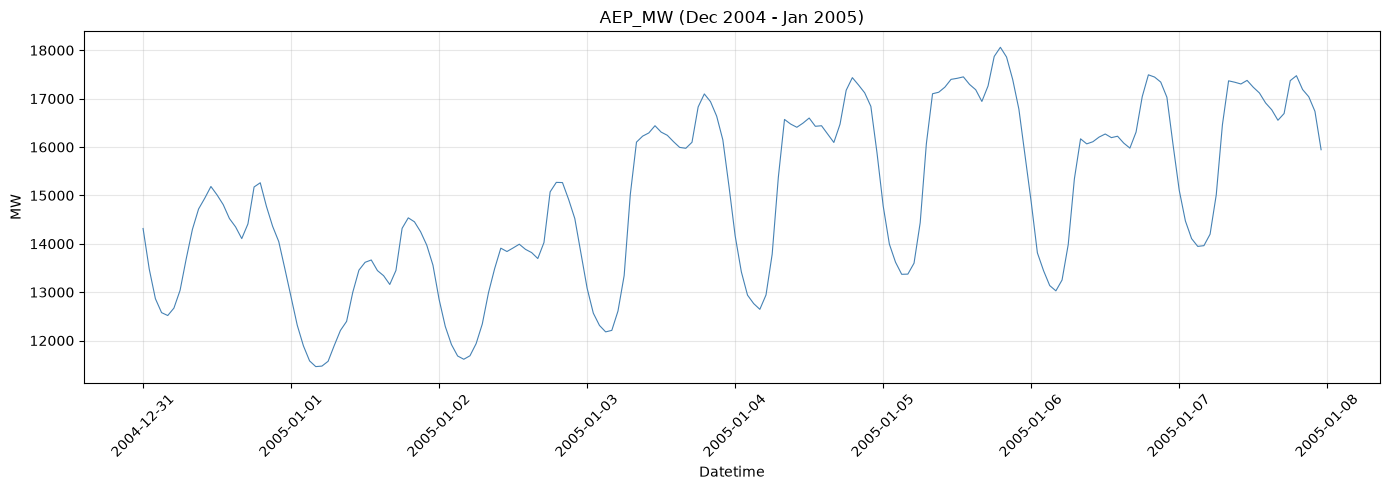

In [16]:
# Sort the index first — this is the only fix needed
df = df.sort_index()

# Now loc will work perfectly
data = df['AEP_MW'].loc['2004-12-31':'2005-01-07']

# Plot
plt.figure(figsize=(14, 5))
plt.plot(data.index, data.values, color='steelblue', linewidth=0.8)
plt.title('AEP_MW (Dec 2004 - Jan 2005)')
plt.xlabel('Datetime')
plt.ylabel('MW')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Splitting the data into training and testing dataset

In [17]:
size = int(len(df)*0.8)
print(size)
train = df.iloc[:size]
test = df.iloc[size:]

97011


In [43]:
FEATURES = ['dayofyear', 'hour', 'dayofweek', 'quarter', 'month', 'year', 'AEP_MW_lag1', 'AEP_MW_lag2', 'AEP_MW_lag3', 'AEP_MW_lag4', 'AEP_MW_lag5']
TARGET = 'AEP_MW'

X_train = train[FEATURES]
y_train = train[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]

## Training the XGBRegressor model

In [44]:
reg = XGBRegressor(base_score=0.5, booster='gbtree',    
                    n_estimators=1000,
                    early_stopping_rounds=50,
                       objective='reg:linear',
                       max_depth=3,
                       learning_rate=0.01)

reg.fit(X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=100)


[0]	validation_0-rmse:15748.68015	validation_1-rmse:14767.91425


c:\Users\bhara\Desktop\Machine Learning Projects\Energy Demand Time Series Forecasting\venv\Lib\site-packages\xgboost\callback.py:385: UserWarning: [21:56:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\objective\regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[100]	validation_0-rmse:5793.40401	validation_1-rmse:5381.13630
[200]	validation_0-rmse:2171.23737	validation_1-rmse:1971.54300
[300]	validation_0-rmse:887.83977	validation_1-rmse:770.25460
[400]	validation_0-rmse:475.97030	validation_1-rmse:412.68348
[500]	validation_0-rmse:366.14478	validation_1-rmse:340.13309
[600]	validation_0-rmse:332.62262	validation_1-rmse:323.92783
[700]	validation_0-rmse:316.84152	validation_1-rmse:313.09967
[800]	validation_0-rmse:305.42714	validation_1-rmse:303.05480
[900]	validation_0-rmse:295.28466	validation_1-rmse:293.42574
[999]	validation_0-rmse:283.93956	validation_1-rmse:282.48671


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:linear'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",0.5
,booster,'gbtree'
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load

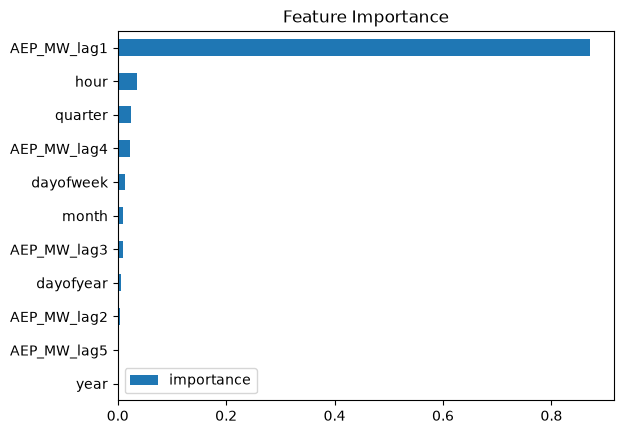

In [45]:
fi = pd.DataFrame(data=reg.feature_importances_,
             index=reg.feature_names_in_,
             columns=['importance'])
fi.sort_values('importance').plot(kind='barh', title='Feature Importance')
plt.show()

### Plot of the Actual and Predicted 

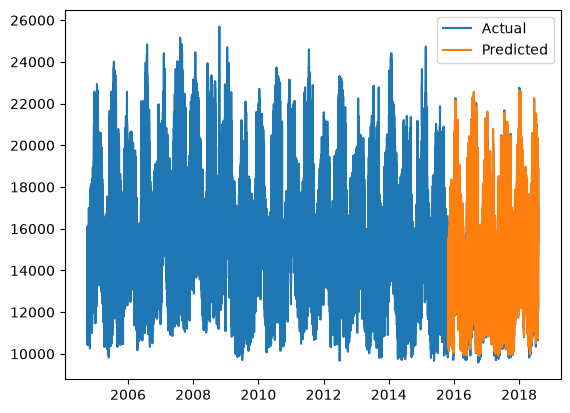

In [46]:
pred = reg.predict(X_test)
plt.plot(df.index,df['AEP_MW'],label="Actual")
plt.plot(X_test.index,pred,label="Predicted")
plt.legend()
plt.show()

## Line plot of only Starting 100 hours of testing data to understand how well the model has performed

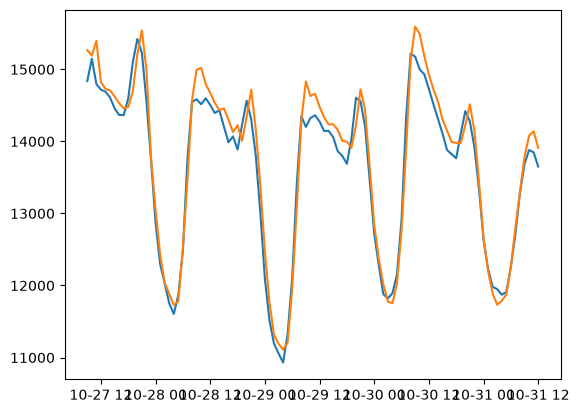

In [47]:
y_test_first = y_test.iloc[0:100]
pred_first  = pred[0:100]
plt.plot(y_test_first.index,y_test_first)
plt.plot(y_test_first.index,pred_first)
plt.show()

In [48]:
print("root_mean_squared_error: ", root_mean_squared_error(pred,y_test))
print("mean_squared_error: ",mean_squared_error(pred,y_test))

root_mean_squared_error:  282.48671132636815
mean_squared_error:  79798.74207598684


## Now If I want to predict the forecast for the next one week this is how it will work

In [24]:
# Last timestamp in your data
last_date = df.index[-1]
print(f"Last date in data: {last_date}")

# Create next 168 hours (7 days x 24 hours)
future_dates = pd.date_range(
    start = last_date + pd.Timedelta(hours=1),
    periods = 168,         # 7 days * 24 hours
    freq = 'h'
)

print(f"Forecast from : {future_dates[0]}")
print(f"Forecast to   : {future_dates[-1]}")

Last date in data: 2018-08-03 00:00:00
Forecast from : 2018-08-03 01:00:00
Forecast to   : 2018-08-10 00:00:00


In [25]:
# Create empty dataframe with future dates
future_df = pd.DataFrame(index=future_dates)
future_df.index.name = 'Datetime'

# Add time features (same ones you used in training)
future_df['hour']       = future_df.index.hour
future_df['dayofweek']  = future_df.index.dayofweek
future_df['quarter']    = future_df.index.quarter
future_df['month']      = future_df.index.month
future_df['year']       = future_df.index.year
future_df['dayofyear']  = future_df.index.dayofyear
# future_df['dayofmonth'] = future_df.index.day
# future_df['weekofyear'] = future_df.index.isocalendar().week.astype(int)

print(future_df.head())

                     hour  dayofweek  quarter  month  year  dayofyear
Datetime                                                             
2018-08-03 01:00:00     1          4        3      8  2018        215
2018-08-03 02:00:00     2          4        3      8  2018        215
2018-08-03 03:00:00     3          4        3      8  2018        215
2018-08-03 04:00:00     4          4        3      8  2018        215
2018-08-03 05:00:00     5          4        3      8  2018        215


In [26]:
# Get last 5 known values for lag initialization
last_known_values = list(df['AEP_MW'].values[-5:])
print(f"Last 5 known values: {last_known_values}")

# Predict hour by hour — each prediction feeds next lag
predictions = []

for i in range(len(future_df)):
    
    # Build lag features from known + predicted values
    future_df.loc[future_df.index[i], 'AEP_MW_lag1'] = last_known_values[-1]
    future_df.loc[future_df.index[i], 'AEP_MW_lag2'] = last_known_values[-2]
    future_df.loc[future_df.index[i], 'AEP_MW_lag3'] = last_known_values[-3]
    future_df.loc[future_df.index[i], 'AEP_MW_lag4'] = last_known_values[-4]
    future_df.loc[future_df.index[i], 'AEP_MW_lag5'] = last_known_values[-5]
    
    # Get feature row for this hour
    row = future_df.iloc[[i]][['dayofyear','hour', 'dayofweek', 'quarter', 'month',
                                'year','AEP_MW_lag1', 
                                'AEP_MW_lag2', 'AEP_MW_lag3', 'AEP_MW_lag4',
                                'AEP_MW_lag5']]
    
    # Predict
    pred = reg.predict(row)[0]
    predictions.append(pred)
    
    # Add prediction to known values for next lag
    last_known_values.append(pred)

print(f"Generated {len(predictions)} hourly predictions")

Last 5 known values: [np.float64(17673.0), np.float64(17303.0), np.float64(17001.0), np.float64(15964.0), np.float64(14809.0)]
Generated 168 hourly predictions


## Below plot shows the prediction for the next one week 

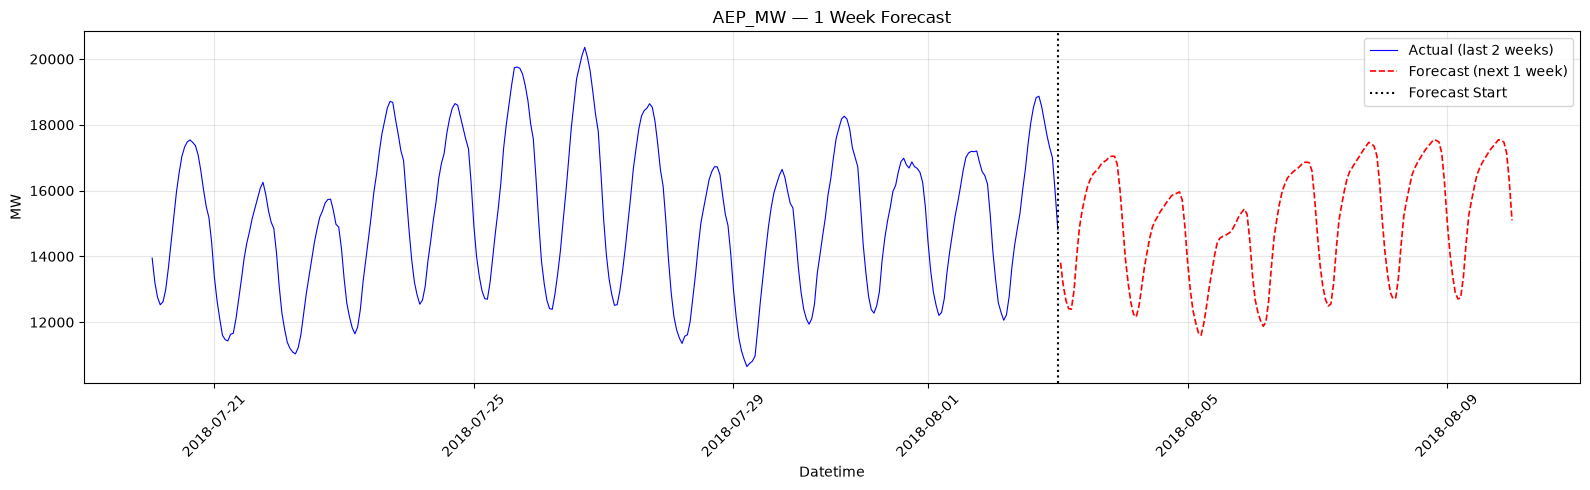

In [27]:
import matplotlib.pyplot as plt

# Store predictions
future_df['AEP_MW_pred'] = predictions

# Take last 2 weeks of actual data for context
actual_tail = df['AEP_MW'].iloc[-336:]   # 14 days for context

# Plot
plt.figure(figsize=(16, 5))

# Actual data (last 2 weeks)
plt.plot(actual_tail.index, actual_tail.values,
         color='blue',
         linewidth=0.8,
         label='Actual (last 2 weeks)')

# Forecast (next 1 week)
plt.plot(future_df.index, future_df['AEP_MW_pred'],
         color='red',
         linewidth=1.2,
         linestyle='--',
         label='Forecast (next 1 week)')

# Mark the boundary
plt.axvline(x=last_date, color='black', 
            linestyle=':', linewidth=1.5, 
            label='Forecast Start')

plt.title('AEP_MW — 1 Week Forecast')
plt.xlabel('Datetime')
plt.ylabel('MW')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
print(future_df['AEP_MW_pred'])

Datetime
2018-08-03 01:00:00    13808.665039
2018-08-03 02:00:00    13123.695312
2018-08-03 03:00:00    12664.664062
2018-08-03 04:00:00    12411.951172
2018-08-03 05:00:00    12394.835938
                           ...     
2018-08-09 20:00:00    17525.492188
2018-08-09 21:00:00    17474.585938
2018-08-09 22:00:00    17144.990234
2018-08-09 23:00:00    16281.606445
2018-08-10 00:00:00    15093.872070
Freq: h, Name: AEP_MW_pred, Length: 168, dtype: float32


### LSTM model for Energy Demand Forecasting

In [57]:
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler

In [58]:
# Use only AEP_MW column for LSTM
# LSTM learns patterns from raw sequence — no need for lag features
data = df[['AEP_MW']].copy()
data = data.dropna()

# Normalize to 0-1 range (LSTM needs this)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

print(f"Data shape  : {scaled_data.shape}")
print(f"Min value   : {scaled_data.min():.4f}")
print(f"Max value   : {scaled_data.max():.4f}")

Data shape  : (121264, 1)
Min value   : 0.0000
Max value   : 1.0000


In [59]:
# LSTM needs data in sequences
# Example: use last 24 hours to predict next hour
# [h1,h2,...,h24] → predict h25

def create_sequences(data,dates, seq_length=24):
    X, y,y_dates = [], [] , []
    for i in range(len(data) - seq_length):
        X.append(data[i : i + seq_length])      # input sequence
        y.append(data[i + seq_length])           # next value to predict
        y_dates.append(dates[i+seq_length])
    return np.array(X), np.array(y), np.array(y_dates)

SEQ_LENGTH = 24   # use last 24 hours to predict next hour

X, y,y_dates = create_sequences(scaled_data,data.index, SEQ_LENGTH)
print(f"X shape : {X.shape}")   # (samples, 24, 1)
print(f"y shape : {y.shape}")   # (samples, 1)

X shape : (121240, 24, 1)
y shape : (121240, 1)


In [60]:
# 80% train, 20% test
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test  = X[train_size:]
y_train = y[:train_size]
y_test  = y[train_size:]

# Convert to PyTorch tensors
X_train = torch.FloatTensor(X_train)
X_test  = torch.FloatTensor(X_test)
y_train = torch.FloatTensor(y_train)
y_test  = torch.FloatTensor(y_test)

print(f"X_train : {X_train.shape}")   # (train_samples, 24, 1)
print(f"X_test  : {X_test.shape}")    # (test_samples,  24, 1)

X_train : torch.Size([96992, 24, 1])
X_test  : torch.Size([24248, 24, 1])


In [61]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, 
                 num_layers=2, output_size=1, dropout=0.2):
        super(LSTMModel, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        
        # LSTM layer
        self.lstm = nn.LSTM(
            input_size  = input_size,    # 1 feature (AEP_MW)
            hidden_size = hidden_size,   # neurons per layer
            num_layers  = num_layers,    # stacked LSTM layers
            batch_first = True,          # input shape: (batch, seq, feature)
            dropout     = dropout        # dropout between layers
        )
        
        # Fully connected output layer
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        # Initialize hidden state
        h0 = torch.zeros(self.num_layers, x.size(0), 
                         self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), 
                         self.hidden_size)
        
        # LSTM forward pass
        out, _ = self.lstm(x, (h0, c0))
        
        # Take output from last time step only
        out = self.fc(out[:, -1, :])
        return out

# Initialize model
model = LSTMModel(
    input_size  = 1,
    hidden_size = 64,
    num_layers  = 2,
    output_size = 1,
    dropout     = 0.2
)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

LSTMModel(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Total parameters: 50,497


In [67]:
# Loss and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# DataLoader for batching
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
train_loader  = DataLoader(
    train_dataset, 
    batch_size = 64,      # process 64 samples at a time
    shuffle    = False    # NEVER shuffle time series data
)

print(f"Batches per epoch : {len(train_loader)}")

Batches per epoch : 1516


In [68]:
EPOCHS = 50
train_losses = []
val_losses   = []

for epoch in range(EPOCHS):
    
    # ── Training ──
    model.train()
    batch_losses = []
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss   = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    
    train_loss = np.mean(batch_losses)
    train_losses.append(train_loss)
    
    # ── Validation ──
    model.eval()
    with torch.no_grad():
        val_output = model(X_test)
        val_loss   = criterion(val_output, y_test).item()
        val_losses.append(val_loss)
    
    # Print every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1:3d}/{EPOCHS}]  "
              f"Train Loss: {train_loss:.6f}  "
              f"Val Loss: {val_loss:.6f}")

print("\nTraining complete ✅")

Epoch [ 10/50]  Train Loss: 0.000268  Val Loss: 0.000213
Epoch [ 20/50]  Train Loss: 0.000191  Val Loss: 0.000170
Epoch [ 30/50]  Train Loss: 0.000161  Val Loss: 0.000146
Epoch [ 40/50]  Train Loss: 0.000143  Val Loss: 0.000146
Epoch [ 50/50]  Train Loss: 0.000129  Val Loss: 0.000146

Training complete ✅


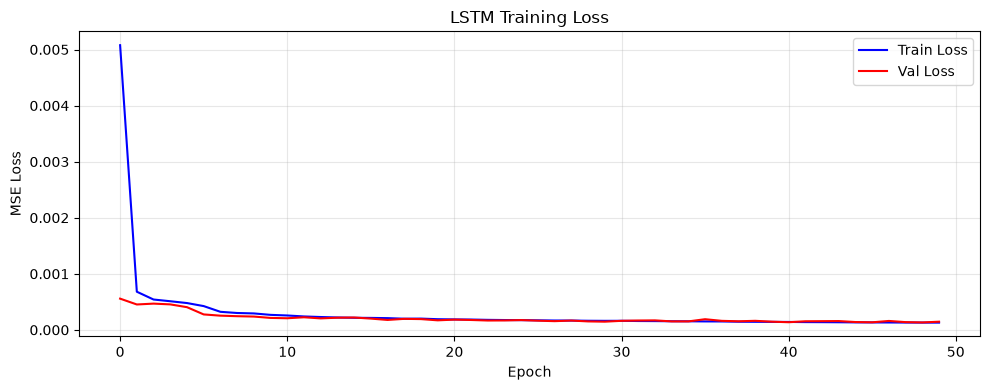

In [69]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss', color='blue')
plt.plot(val_losses,   label='Val Loss',   color='red')
plt.title('LSTM Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [70]:
model.eval()
with torch.no_grad():
    test_pred = model(X_test).numpy()
    
# Inverse transform back to original scale
test_pred_original = scaler.inverse_transform(test_pred)
y_test_original    = scaler.inverse_transform(y_test.numpy())

# Metrics
mae  = mean_absolute_error(y_test_original, test_pred_original)
mse = mean_squared_error(y_test_original,test_pred_original)
rmse = np.sqrt(mean_squared_error(y_test_original, test_pred_original))
mape = np.mean(np.abs((y_test_original - test_pred_original) 
                       / y_test_original)) * 100

print(f"MAE  : {mae:.2f}")
print(f"MSE : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

MAE  : 143.97
MSE : 37914.87
RMSE : 194.72
MAPE : 0.96%


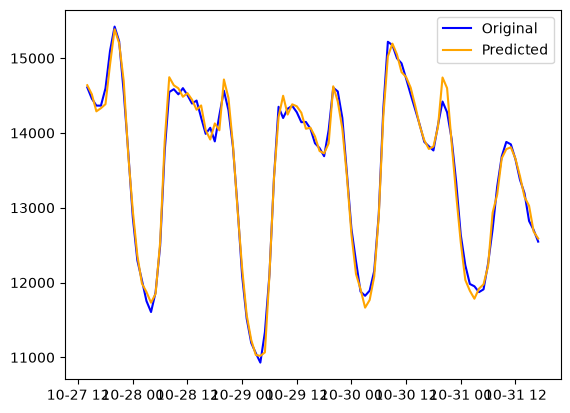

In [71]:
y_test_original = y_test_original.reshape(-1)
test_pred_original = test_pred_original.reshape(-1)

plt.plot(y_dates[train_size:train_size+100],y_test_original[:100],color='blue',label="Original")
plt.plot(y_dates[train_size:train_size+100],test_pred_original[:100],color="orange",label='Predicted')
plt.legend()
plt.show()


In [72]:
# Last timestamp in your data
last_date = df.index[-1]
print(f"Last date in data: {last_date}")

# Create next 168 hours (7 days x 24 hours)
future_dates = pd.date_range(
    start = last_date + pd.Timedelta(hours=1),
    periods = 168,         # 7 days * 24 hours
    freq = 'h'
)

print(f"Forecast from : {future_dates[0]}")
print(f"Forecast to   : {future_dates[-1]}")

# Create empty dataframe with future dates
future_df = pd.DataFrame(index=future_dates)
future_df.index.name = 'Datetime'

Last date in data: 2018-08-03 00:00:00
Forecast from : 2018-08-03 01:00:00
Forecast to   : 2018-08-10 00:00:00


In [78]:
 # Get last 5 known values for lag initialization
last_known_values = list(df['AEP_MW'].values[-24:])
print(f"Last 24 known values: {last_known_values}")

# Predict hour by hour — each prediction feeds next lag
predictions = []

for i in range(len(future_df)):
    
    # Build lag features from known + predicted values
    future_df.loc[future_df.index[i], 'h1'] = last_known_values[-1]
    future_df.loc[future_df.index[i], 'h2'] = last_known_values[-2]
    future_df.loc[future_df.index[i], 'h3'] = last_known_values[-3]
    future_df.loc[future_df.index[i], 'h4'] = last_known_values[-4]
    future_df.loc[future_df.index[i], 'h5'] = last_known_values[-5]
    future_df.loc[future_df.index[i], 'h6'] = last_known_values[-6]
    future_df.loc[future_df.index[i], 'h7'] = last_known_values[-7]
    future_df.loc[future_df.index[i], 'h8'] = last_known_values[-8]
    future_df.loc[future_df.index[i], 'h9'] = last_known_values[-9]
    future_df.loc[future_df.index[i], 'h10'] = last_known_values[-10]
    future_df.loc[future_df.index[i], 'h11'] = last_known_values[-11]
    future_df.loc[future_df.index[i], 'h12'] = last_known_values[-12]
    future_df.loc[future_df.index[i], 'h13'] = last_known_values[-13]
    future_df.loc[future_df.index[i], 'h14'] = last_known_values[-14]
    future_df.loc[future_df.index[i], 'h15'] = last_known_values[-15]
    future_df.loc[future_df.index[i], 'h16'] = last_known_values[-16]
    future_df.loc[future_df.index[i], 'h17'] = last_known_values[-17]
    future_df.loc[future_df.index[i], 'h18'] = last_known_values[-18]
    future_df.loc[future_df.index[i], 'h19'] = last_known_values[-19]
    future_df.loc[future_df.index[i], 'h20'] = last_known_values[-20]
    future_df.loc[future_df.index[i], 'h21'] = last_known_values[-21]
    future_df.loc[future_df.index[i], 'h22'] = last_known_values[-22]
    future_df.loc[future_df.index[i], 'h23'] = last_known_values[-23]
    future_df.loc[future_df.index[i], 'h24'] = last_known_values[-24]
    
    # Get feature row for this hour
    row = future_df.iloc[[i]][['h1','h2','h3','h4','h5','h6','h7','h8','h9','h10',
                               'h11','h12','h13','h14','h15','h16','h17','h18','h19','h20',
                               'h21','h22','h23','h24']]
    
    row1 = scaler.fit_transform(row)
    row1 = torch.FloatTensor(row1)
    # Predict
    model.eval()
    with torch.no_grad():
        pred = model(row1).numpy()
    pred = scaler.inverse_transform(pred)
    predictions.append(pred)
    
    # Add prediction to known values for next lag
    last_known_values.append(pred)

print(f"Generated {len(predictions)} hourly predictions")   
    
    


Last 24 known values: [np.float64(13286.0), np.float64(12587.0), np.float64(12296.0), np.float64(12059.0), np.float64(12224.0), np.float64(12781.0), np.float64(13661.0), np.float64(14326.0), np.float64(14834.0), np.float64(15309.0), np.float64(16025.0), np.float64(16651.0), np.float64(17423.0), np.float64(18067.0), np.float64(18534.0), np.float64(18826.0), np.float64(18869.0), np.float64(18562.0), np.float64(18118.0), np.float64(17673.0), np.float64(17303.0), np.float64(17001.0), np.float64(15964.0), np.float64(14809.0)]


RuntimeError: For unbatched 2-D input, hx and cx should also be 2-D but got (3-D, 3-D) tensors

In [ ]:
from collections import deque

# Keep original values
lags = deque(df['AEP_MW'].values[-24:], maxlen=24)

predictions = []

model.eval()

for i in range(24*7):     # 168 hours

    # Original values
    x_original = np.array(lags).reshape(1,-1)

    # Create scaled copy
    x_scaled = scaler.transform(x_original)

    # Shape for LSTM
    x_scaled = x_scaled.reshape(1,24,1)

    x_scaled = torch.FloatTensor(x_scaled)

    # Predict
    with torch.no_grad():
        pred_scaled = model(x_scaled).numpy()

    # Convert prediction back to original scale
    pred_original = target_scaler.inverse_transform(pred_scaled)

    pred_value = pred_original[0,0]

    # Store prediction
    predictions.append(pred_value)

    # Add original-scale prediction to lag list
    lags.append(pred_value)

NameError: name 'feature_scaler' is not defined